# Lib Installation

In [1]:
!pip install  lightning pytorch-lightning torchvision  tqdm python-dotenv PyYAML wilds

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 22.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 7.3 MB/s eta 0:00:00


# Config

In [3]:
config = {
    "algo": "FOND",
    "dataset": ["DomainNet"],  # Only DomainNet
    "test_set_id": 0,  # 0, 1, 2, etc. for your splits if applicable
    # Paths
    "data_dir": {"DomainNet": "/kaggle/input/domainnet/DomainNet"},  # Path to DomainNet root
    "log_dir": "./logs",
    # Training settings
    "n_epochs": 5001,  # Converted from 5001 steps (~15 epochs at 32 batch size)
    "checkpoint_freq": 4999,  # Evaluate every epoch (was 300 steps)
    "holdout_fraction": 0.2,
    # Model checkpointing
    "model_checkpoint": {
        "metric": "val/oacc",
        "maximize": True
    },
    # Seeds
    "overall_seed": 1,
    "trial_id": 0,
    "hparam_id": 0,  # 0=default hparams, 1-4=random variants
    # System
    "num_workers": 4,
    # Dataset config (from sweep)
    "overlap": "high",  # Can remove or leave as placeholder
    "num_classes": 345,  # DomainNet has 345 classes
    "num_domain_linked_classes": None,
    # AutoFOND specific
    "auto_augment": False,  # Can enable later
    "augment_search_epochs": 5,
    "augment_policy_size": 5,
    "augment_num_policies": 3,
    # Teacher paths (empty for regular FOND)
    "teacher_paths": {}
}


# Imports

In [4]:
import math
from typing import List, Any, Dict, Optional, Callable, Tuple
import argparse
import logging
import hashlib
import numpy as np
from collections import Counter
import collections
import time
from datetime import datetime
import lightning as L
from tqdm import tqdm
import csv
import json
from pathlib import Path
import os
import torch
import torchmetrics
import torchvision.datasets.folder
from PIL import Image, ImageFile
from torch.utils.data import ConcatDataset, Dataset, Subset, TensorDataset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.transforms.functional import rotate
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models


# SRC

## Domain Creation

In [5]:



def create_domains(
    num_classes: int, num_linked: int, num_train_domains: int
) -> List[List[int]]:
    """
    Determine and distribute domain-linked and domain-shared classes.
    Domain-linked classes will come from the same domain, i.e., idx=0.
    Domain-shared classes will exist in each of the remaining domains

    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_train_domains: number of different training domains
    """
    assert num_linked <= num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    domain_linked = [i for i in range(num_linked)]
    logging.info(f"Domain-shared classes: {domain_shared}")
    logging.info(f"Domain-linked classes: {domain_linked}")
    # domains = [domain_shared.copy() for i in range(num_train_domains)]
    domains = [[] for i in range(num_train_domains)]

    # first domain is domain-linked only
    domains[0] = domain_linked
    # other domains contain domain-shared only
    domains[1:] = [domain_shared.copy() for i in range(1, num_train_domains)]

    logging.info(f"domains[0]: {domains[0]}")
    logging.info(f"domains[1:]: {domains[1:]}")

    return domains


def create_domains_1(
    num_classes: int, num_linked: int, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked: number of classes that are linked to an individual domain
        num_domains: number of different domains, including test domain
    """
    assert num_linked < num_classes
    domain_shared = [i for i in range(num_linked, num_classes)]
    print(f"Shared classes: {domain_shared}")
    num_train_domains = num_domains - 1
    domains = [domain_shared.copy() for i in range(num_train_domains)]

    for class_idx in range(num_linked):
        domain_idx = class_idx % num_train_domains
        domains[domain_idx].append(class_idx)
    return domains


def create_domains_2(
    num_classes: int, num_linked_ratio: float, num_domains: int
) -> List[List[int]]:
    """
    Args:
        num_classes: number of overall classes within all the domains
        num_linked_ratio: ratio of linked classes to the total number of classes
        num_domains: number of different domains, including test domain
    """
    num_linked = math.floor(num_linked_ratio * num_classes)
    return create_domains_1(num_classes, num_linked, num_domains)



# Testing
create_domains(num_classes=10, num_linked=5, num_train_domains=3)
# Testing domain linked only
create_domains(num_classes=10, num_linked=10, num_train_domains=3)

# Testing same classes with different overlap
domains = create_domains_1(num_classes=10, num_linked=3, num_domains=4)
print(domains)
domains = create_domains_1(num_classes=10, num_linked=5, num_domains=4)
print(domains)

# Testing different classes with same overlap percentage
domains = create_domains_2(num_classes=10, num_linked_ratio=0.2, num_domains=4)
print(domains)
domains = create_domains_2(num_classes=5, num_linked_ratio=0.2, num_domains=4)
print(domains)


Shared classes: [3, 4, 5, 6, 7, 8, 9]
[[3, 4, 5, 6, 7, 8, 9, 0], [3, 4, 5, 6, 7, 8, 9, 1], [3, 4, 5, 6, 7, 8, 9, 2]]
Shared classes: [5, 6, 7, 8, 9]
[[5, 6, 7, 8, 9, 0, 3], [5, 6, 7, 8, 9, 1, 4], [5, 6, 7, 8, 9, 2]]
Shared classes: [2, 3, 4, 5, 6, 7, 8, 9]
[[2, 3, 4, 5, 6, 7, 8, 9, 0], [2, 3, 4, 5, 6, 7, 8, 9, 1], [2, 3, 4, 5, 6, 7, 8, 9]]
Shared classes: [1, 2, 3, 4]
[[1, 2, 3, 4, 0], [1, 2, 3, 4], [1, 2, 3, 4]]


## Hparams

In [6]:
"""
Hyper-parameter registry
"""


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def _define_hparam(hparams, hparam_name, default_val, random_val_fn):
    hparams[hparam_name] = (hparams, hparam_name, default_val, random_val_fn)


def _hparams(algorithm, dataset, random_seed):
    """
    Global registry of hyperparams. Each entry is a (default, random) tuple.
    New algorithms / networks / etc. should add entries here.
    """
    SMALL_IMAGES = ["Debug28", "RotatedMNIST", "ColoredMNIST"]

    hparams = {}

    def _hparam(name, default_val, random_val_fn):
        """Define a hyperparameter. random_val_fn takes a RandomState and
        returns a random hyperparameter value."""
        assert name not in hparams
        random_state = np.random.RandomState(seed_hash(random_seed, name))
        hparams[name] = (default_val, random_val_fn(random_state))

    # Unconditional hparam definitions.

    _hparam("data_augmentation", True, lambda r: True)
    _hparam("resnet18", True, lambda r: True)
    _hparam("resnet_dropout", 0.0, lambda r: r.choice([0.0, 0.1, 0.5]))
    _hparam("class_balanced", False, lambda r: False)
    _hparam("nonlinear_classifier", False, lambda r: False)

    # Algorithm-specific hparam definitions. Each block of code below
    # corresponds to exactly one algorithm.

    if (
        algorithm == "FOND"
        or algorithm == "FOND_NC"
        or algorithm == "FOND_N"
        or algorithm == "NOC"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
    elif (
        algorithm == "FOND_Distillation_Separate_Projector"
        or algorithm == "FOND_Distillation_Teacher_Projector"
        or algorithm == "FOND_Distillation_Student_Projector"
    ):
        _hparam("temperature", 0.07, lambda r: 0.07 * r.uniform(0.75, 1.25))
        _hparam("base_temperature", 0.07, lambda r: 0.07)
        _hparam("xdom_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("error_lmbd", 1, lambda r: 10 ** r.uniform(-1, 3))
        _hparam("xda_alpha", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("xda_beta", 1, lambda r: 10 ** r.uniform(0, 1))
        _hparam("distillation_temperature", 1, lambda r: r.uniform(1, 20))

    # Dataset-and-algorithm-specific hparam definitions. Each block of code
    # below corresponds to exactly one hparam. Avoid nested conditionals.

    if dataset in SMALL_IMAGES:
        _hparam("lr", 1e-3, lambda r: 10 ** r.uniform(-4.5, -2.5))
    else:
        _hparam("lr", 5e-5, lambda r: 10 ** r.uniform(-5, -3.5))

    if dataset in SMALL_IMAGES:
        _hparam("weight_decay", 0.0, lambda r: 0.0)
    else:
        _hparam("weight_decay", 0.0, lambda r: 10 ** r.uniform(-6, -2))

    if dataset in SMALL_IMAGES:
        _hparam("batch_size", 64, lambda r: int(2 ** r.uniform(3, 9)))
    elif algorithm == "ARM":
        _hparam("batch_size", 8, lambda r: 8)
    elif dataset == "DomainNet":
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5)))
    else:
        _hparam("batch_size", 32, lambda r: int(2 ** r.uniform(3, 5.5)))

    return hparams


def default_hparams(algorithm, dataset):
    return {a: b for a, (b, c) in _hparams(algorithm, dataset, 0).items()}


def random_hparams(algorithm, dataset, seed):
    return {a: c for a, (b, c) in _hparams(algorithm, dataset, seed).items()}


## Misc

In [7]:

class _SplitDataset(torch.utils.data.Dataset):
    """Used by split_dataset"""

    def __init__(self, underlying_dataset, keys):
        super(_SplitDataset, self).__init__()
        self.underlying_dataset = underlying_dataset
        self.keys = keys

    def __getitem__(self, key):
        return self.underlying_dataset[self.keys[key]]

    def __len__(self):
        return len(self.keys)


def split_dataset(dataset, n, seed=0):
    """
    Return a pair of datasets corresponding to a random split of the given
    dataset, with n datapoints in the first dataset and the rest in the last,
    using the given random seed
    """
    assert n <= len(dataset)
    keys = list(range(len(dataset)))
    np.random.RandomState(seed).shuffle(keys)
    keys_1 = keys[:n]
    keys_2 = keys[n:]
    return _SplitDataset(dataset, keys_1), _SplitDataset(dataset, keys_2)


def seed_hash(*args):
    """
    Derive an integer hash from all args, for use as a random seed.
    """
    args_str = str(args)
    return int(hashlib.md5(args_str.encode("utf-8")).hexdigest(), 16) % (2**31)


def make_weights_for_balanced_classes(dataset):
    counts = Counter()
    classes = []
    for _, y in dataset:
        y = int(y)
        counts[y] += 1
        classes.append(y)

    n_classes = len(counts)

    weight_per_class = {}
    for y in counts:
        weight_per_class[y] = 1 / (counts[y] * n_classes)

    weights = torch.zeros(len(dataset))
    for i, y in enumerate(classes):
        weights[i] = weight_per_class[int(y)]

    return weights
def compute_loss(network, loader, device):
    """
    Compute average loss for a given loader.
    Returns: average loss value
    """
    total_loss = 0.0
    num_batches = 0
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            # Compute loss
            loss = torch.nn.functional.cross_entropy(p, y, reduction='mean')
            total_loss += loss.item()
            num_batches += 1
    
    network.train()
    
    avg_loss = total_loss / num_batches if num_batches > 0 else 0.0
    return avg_loss

def accuracy(network, loader, weights, device, dataset):
    correct = 0
    total = 0
    weights_offset = 0
    overlapping_classes = dataset.overlapping_classes
    num_classes = dataset.num_classes
    
    f1_score = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    per_class_accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average=None,
    ).to(device)
    accuracy = torchmetrics.Accuracy(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    recall = torchmetrics.Recall(
        task="multiclass",
        num_classes=num_classes,
        average="macro",
    ).to(device)
    precision = torchmetrics.Precision(
        task='multiclass',  # ✅ Fixed typo
        num_classes=num_classes,
        average='macro'
    ).to(device)
    conf_mat = torchmetrics.ConfusionMatrix(
        task="multiclass",
        num_classes=num_classes
    ).to(device)  # ✅ Added .to(device)
    
    network.eval()
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            p = network.predict(x)
            
            if weights is None:
                batch_weights = torch.ones(len(x))
            else:
                batch_weights = weights[weights_offset : weights_offset + len(x)]
                weights_offset += len(x)
            batch_weights = batch_weights.to(device)
            
            if p.size(1) == 1:
                correct += (
                    (p.gt(0).eq(y).float() * batch_weights.view(-1, 1)).sum().item()
                )
            else:
                correct += (p.argmax(1).eq(y).float() * batch_weights).sum().item()
            total += batch_weights.sum().item()
            
            # update metrics
            accuracy.update(p, y)
            recall.update(p, y)
            precision.update(p, y)
            f1_score.update(p, y)
            per_class_accuracy.update(p, y)
            conf_mat.update(p, y)
    
    network.train()
    compute_acc = accuracy.compute().item()
    compute_recall = recall.compute().item()
    compute_precision = precision.compute().item()  # ✅ Fixed typo
    compute_f1 = f1_score.compute().item()
    compute_per_class_acc = per_class_accuracy.compute().cpu().numpy()
    cm_compute = conf_mat.compute().cpu().numpy()  # ✅ Convert to numpy
    
    overlap_class_acc = []
    non_overlap_class_acc = []
    per_class_acc_dict = {}
    for i in range(num_classes):
        per_class_acc_dict[i] = float(compute_per_class_acc[i])
        if i in overlapping_classes:
            overlap_class_acc.append(compute_per_class_acc[i])
        else:
            non_overlap_class_acc.append(compute_per_class_acc[i])
    
    if len(non_overlap_class_acc) == 0:
        non_overlap_class_acc = -1
    else:
        non_overlap_class_acc = np.mean(non_overlap_class_acc)
    if len(overlap_class_acc) == 0:
        overlap_class_acc = -1
    else:
        overlap_class_acc = np.mean(overlap_class_acc)
    
    other_acc = correct / total
    
    return (
        float(compute_acc),
        float(compute_recall),
        float(compute_f1),
        float(compute_precision),      # ✅ Moved before oacc/nacc
        float(overlap_class_acc),
        float(non_overlap_class_acc),
        per_class_acc_dict,
        cm_compute
    )
class _InfiniteSampler(torch.utils.data.Sampler):
    """Wraps another Sampler to yield an infinite stream."""

    def __init__(self, sampler):
        self.sampler = sampler

    def __iter__(self):
        while True:
            for batch in self.sampler:
                yield batch


class InfiniteDataLoader:
    def __init__(self, dataset, weights, batch_size, num_workers):
        super().__init__()

        if weights is not None:
            sampler = torch.utils.data.WeightedRandomSampler(
                weights, replacement=True, num_samples=batch_size
            )
        else:
            sampler = torch.utils.data.RandomSampler(dataset, replacement=True)

        if weights == None:
            weights = torch.ones(len(dataset))

        batch_sampler = torch.utils.data.BatchSampler(
            sampler, batch_size=batch_size, drop_last=True
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

    def __iter__(self):
        while True:
            yield next(self._infinite_iterator)

    def __len__(self):
        raise ValueError


class FastDataLoader:
    """DataLoader wrapper with slightly improved speed by not respawning worker
    processes at every epoch."""

    def __init__(self, dataset, batch_size, num_workers):
        super().__init__()

        batch_sampler = torch.utils.data.BatchSampler(
            torch.utils.data.RandomSampler(dataset, replacement=False),
            batch_size=batch_size,
            drop_last=False,
        )

        self._infinite_iterator = iter(
            torch.utils.data.DataLoader(
                dataset,
                num_workers=num_workers,
                batch_sampler=_InfiniteSampler(batch_sampler),
            )
        )

        self._length = len(batch_sampler)

    def __iter__(self):
        for _ in range(len(self)):
            yield next(self._infinite_iterator)

    def __len__(self):
        return self._length


def config_logging():
    """
    Reusable code for formatting the logger
    """
    logging.basicConfig(
        format="%(asctime)s,%(msecs)03d %(levelname)-8s [%(filename)s:%(funcName)s:%(lineno)d] %(message)s",
        datefmt="%Y-%m-%d:%H:%M:%S",
        level=logging.INFO,
    )


## Simple Logger

In [8]:
"""
Simple CSV logger to replace W&B during development
Keeps the same interface for easy swap later
"""
class CSVLogger:
    """Lightweight logger that writes metrics to CSV"""
    
    def __init__(self, csv_path: str, root_dir:str=None):
        self.csv_path = Path(csv_path)
        self.csv_path.parent.mkdir(parents=True, exist_ok=True)
        self.fieldnames = None
        self.file = None
        self.writer = None
        self._init_csv()
        self.root = root_dir if root_dir is not None else csv_path.parent
    def _init_csv(self):
        """Initialize CSV file with headers"""
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = None  # Will be created on first log
    def return_root(self):
        return self.root
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        """
        Log metrics to CSV
        
        Args:
            metrics: Dictionary of metric_name -> value
            step: Training step (optional, will be added if provided)
        """
        if step is not None:
            metrics = {"step": step, **metrics}
            
        # Flatten nested dictionaries (e.g., {"train/acc": 0.9})
        flat_metrics = {}
        for key, value in metrics.items():
            if isinstance(value, dict):
                for subkey, subvalue in value.items():
                    flat_metrics[f"{key}/{subkey}"] = subvalue
            else:
                flat_metrics[key] = value
        
        # Initialize writer with fieldnames on first call
        if self.writer is None:
            self.fieldnames = list(flat_metrics.keys())
            self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
            self.writer.writeheader()
            
        # Add new fields if they appear
        new_fields = set(flat_metrics.keys()) - set(self.fieldnames)
        if new_fields:
            self.fieldnames.extend(sorted(new_fields))
            # Rewrite file with new headers
            self.file.close()
            self._rewrite_with_new_fields(flat_metrics)
            return
            
        self.writer.writerow(flat_metrics)
        self.file.flush()  # Ensure immediate write
        
    def _rewrite_with_new_fields(self, new_row: Dict[str, Any]):
        """Rewrite CSV when new fields are discovered"""
        # Read existing rows
        with open(self.csv_path, 'r') as f:
            reader = csv.DictReader(f)
            existing_rows = list(reader)
        
        # Rewrite with updated fieldnames
        self.file = open(self.csv_path, 'w', newline='')
        self.writer = csv.DictWriter(self.file, fieldnames=self.fieldnames)
        self.writer.writeheader()
        for row in existing_rows:
            self.writer.writerow(row)
        self.writer.writerow(new_row)
        self.file.flush()
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        """Save experiment config as JSON"""
        if path is None:
            path = self.csv_path.parent / "config.json"
        with open(path, 'w') as f:
            json.dump(config, f, indent=2)
            
    def close(self):
        """Close CSV file"""
        if self.file:
            self.file.close()
            
    def __enter__(self):
        return self
        
    def __exit__(self, exc_type, exc_val, exc_tb):
        self.close()


class PrintLogger:
    """Even simpler logger that just prints to console"""
    
    def log(self, metrics: Dict[str, Any], step: Optional[int] = None):
        step_str = f"[Step {step}] " if step is not None else ""
        metric_str = ", ".join(f"{k}={v:.4f}" if isinstance(v, float) else f"{k}={v}" 
                               for k, v in metrics.items())
        print(f"{step_str}{metric_str}")
        
    def save_config(self, config: Dict[str, Any], path: Optional[str] = None):
        print(f"Config: {json.dumps(config, indent=2)}")
        
    def close(self):
        pass


# Fast Auto Augment

In [9]:
# ===========================
# FAST AUTOAUGMENT DEFINITIONS
# ===========================
import random
import PIL
import PIL.ImageOps
import PIL.ImageEnhance
import PIL.ImageDraw
import numpy as np
from torchvision.transforms.transforms import Compose

random_mirror = True

# -----------------------
# Basic augmentation functions
# -----------------------
def ShearX(img, v):
    assert -0.3 <= v <= 0.3
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, v, 0, 0, 1, 0))

def ShearY(img, v):
    assert -0.3 <= v <= 0.3
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, v, 1, 0))

def TranslateX(img, v):
    assert -0.45 <= v <= 0.45
    if random_mirror and random.random() > 0.5:
        v = -v
    v = v * img.size[0]
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, v, 0, 1, 0))

def TranslateY(img, v):
    assert -0.45 <= v <= 0.45
    if random_mirror and random.random() > 0.5:
        v = -v
    v = v * img.size[1]
    return img.transform(img.size, PIL.Image.AFFINE, (1, 0, 0, 0, 1, v))

def Rotate(img, v):
    assert -30 <= v <= 30
    if random_mirror and random.random() > 0.5:
        v = -v
    return img.rotate(v)

def AutoContrast(img, _):
    return PIL.ImageOps.autocontrast(img)

def Invert(img, _):
    return PIL.ImageOps.invert(img)

def Equalize(img, _):
    return PIL.ImageOps.equalize(img)

def Solarize(img, v):
    assert 0 <= v <= 256
    return PIL.ImageOps.solarize(img, v)

def Posterize(img, v):
    assert 4 <= v <= 8
    return PIL.ImageOps.posterize(img, int(v))

def Contrast(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Contrast(img).enhance(v)

def Color(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Color(img).enhance(v)

def Brightness(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Brightness(img).enhance(v)

def Sharpness(img, v):
    assert 0.1 <= v <= 1.9
    return PIL.ImageEnhance.Sharpness(img).enhance(v)

def Cutout(img, v):
    assert 0.0 <= v <= 0.2
    if v <= 0.:
        return img
    v = v * img.size[0]
    return CutoutAbs(img, v)

def CutoutAbs(img, v):
    if v < 0:
        return img
    w, h = img.size
    x0 = np.random.uniform(0, w)
    y0 = np.random.uniform(0, h)
    x0 = int(max(0, x0 - v / 2.))
    y0 = int(max(0, y0 - v / 2.))
    x1 = min(w, x0 + v)
    y1 = min(h, y0 + v)
    xy = (x0, y0, x1, y1)
    color = (125, 123, 114)
    img = img.copy()
    PIL.ImageDraw.Draw(img).rectangle(xy, color)
    return img

# -----------------------
# List of augmentations
# -----------------------
def augment_list():
    return [
        ("ShearX", ShearX),
        ("ShearY", ShearY),
        ("TranslateX", TranslateX),
        ("TranslateY", TranslateY),
        ("Rotate", Rotate),
        ("AutoContrast", AutoContrast),
        ("Invert", Invert),
        ("Equalize", Equalize),
        ("Solarize", Solarize),
        ("Posterize", Posterize),
        ("Contrast", Contrast),
        ("Color", Color),
        ("Brightness", Brightness),
        ("Sharpness", Sharpness),
        ("Cutout", Cutout)
    ]

# -----------------------
# Fast AutoAugment class
# -----------------------
class FastAutoAugment:
    def __init__(self, policy):
        self.policy = policy
        self.augment_list = {name: func for name, func in augment_list()}

    def __call__(self, img):
        policy = random.choice(self.policy)  # pick one policy
        for op_name, prob, level in policy:
            if random.random() < prob:
                func = self.augment_list[op_name]
                img = func(img, level)
        return img

# -----------------------
# Example CIFAR-10 style policy
# You can replace this with any other policy
# -----------------------
example_policy = [
    [("Invert", 0.7, 1), ("Contrast", 0.5, 1)],
    [("Rotate", 0.6, 30), ("Sharpness", 0.5, 2)],
    [("Color", 0.6, 1), ("ShearX", 0.8, 0.3)]
]

# -----------------------
# Helper to create transform
# -----------------------
def get_fast_autoaugment_transform():
    return FastAutoAugment(example_policy)


In [10]:
from torchvision import transforms
import random

def get_fast_autoaugment_transform():
    """
    A simplified Fast AutoAugment-like transform using torchvision only.
    """
    return transforms.Compose([
        transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1
        ),
        transforms.RandomGrayscale(p=0.1),
        transforms.RandomRotation(degrees=15),
    ])


# Dataset

## Base

In [11]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

# ===========================
# DATASET DEFINITIONS
# ===========================
DATASETS2 = [
    # Debug
    "Debug28",
    "Debug224",
    # Small images
    "ColoredMNIST",
    "RotatedMNIST",
    # Big images
    "VLCS",
    "PACS",
    "OfficeHome",
    "TerraIncognita",
    "DomainNet",
    "SVIRO",
    # WILDS datasets
    "WILDSCamelyon",
    "WILDSFMoW",
    # Spawrious datasets
    "SpawriousO2O_easy",
    "SpawriousO2O_medium",
    "SpawriousO2O_hard",
    "SpawriousM2M_easy",
    "SpawriousM2M_medium",
    "SpawriousM2M_hard",
]

SPECIAL_OVERLAP_TYPES = ["0", "low", "high", "low_linked_only", "high_linked_only"]
OVERLAP_TYPES = SPECIAL_OVERLAP_TYPES


# -----------------------
# DOMAIN CLASS SPLITTING
# -----------------------
def get_domain_classes(N_c, N_oc, repeat, N_s, seed):
    """
    Create a list of classes per domain with overlapping and non-overlapping classes.
    """
    N_noc = N_c - N_oc
    Q = []
    C = list(range(N_c))
    random_state = np.random.RandomState(seed)

    # Non-overlapping classes
    C_noc = list(random_state.choice(C, replace=False, size=N_noc))
    C_oc = [x for x in C if x not in C_noc]

    # Add to queue
    Q.extend(C_noc + list(np.repeat(C_oc, repeat)))

    # Round-robin assignment
    domain_classes = [Q[i::N_s] for i in range(N_s)]

    # Assert overlapping classes
    overlap = np.zeros(N_c)
    for cls_list in domain_classes:
        np.add.at(overlap, cls_list, 1)
    assert C_oc == list(np.where(overlap > 1)[0])

    print("C_noc", C_noc)
    print("C_oc", C_oc)
    print("Q", Q)
    print("domain_classes", domain_classes)
    return domain_classes


# -----------------------
# IMAGE FOLDER WITH CLASS FILTERING
# -----------------------
class DomainBedImageFolder(ImageFolder):
    """
    Custom ImageFolder allowing class removal/selection per environment.
    """
    def __init__(self, root, transform=None, target_transform=None,
                 remove_classes=[], allowed_classes=[], is_test_env=None,
                 env_name=None):
        super().__init__(root, transform, target_transform)
        self.is_test_env = is_test_env
        self.allowed_classes = allowed_classes
        self.remove_classes = remove_classes
        self.env_name = env_name

        old_samples = self.samples
        self.samples, self.targets = [], []
        for sample in old_samples:
            _, target = sample
            if target not in remove_classes:
                self.samples.append(sample)
                self.targets.append(target)

        self.imgs = self.samples
        self.classes = list(set(self.targets))

    def __len__(self):
        return len(self.samples)

    def __str__(self):
        return (f"{self.env_name}: is_test_env={self.is_test_env}, allowed_classes={self.allowed_classes}, "
                f"list(set(self.targets))={self.classes}, num_samples={len(self)}")


def get_overlapping_classes(class_split: List[List[int]], num_classes: int) -> List[int]:
    overlap = np.zeros(num_classes)
    for data in class_split:
        np.add.at(overlap, data, 1)
    return list(np.where(overlap > 1)[0])


# -----------------------
# MULTI-ENVIRONMENT BASE CLASSES
# -----------------------
class MultipleDomainDataset:
    N_STEPS = 5001
    CHECKPOINT_FREQ = 100
    N_WORKERS = 8
    ENVIRONMENTS = None
    INPUT_SHAPE = None

    def __getitem__(self, index):
        return self.datasets[index]

    def __len__(self):
        return len(self.datasets)


# -----------------------
# DEBUG DATASETS
# -----------------------
class Debug(MultipleDomainDataset):
    def __init__(self, root, test_envs, hparams):
        super().__init__()
        self.input_shape = self.INPUT_SHAPE
        self.num_classes = 2
        self.datasets = [
            TensorDataset(torch.randn(16, *self.INPUT_SHAPE),
                          torch.randint(0, self.num_classes, (16,)))
            for _ in range(3)
        ]

class Debug28(Debug):
    INPUT_SHAPE = (3, 28, 28)
    ENVIRONMENTS = ["0", "1", "2"]

class Debug224(Debug):
    INPUT_SHAPE = (3, 224, 224)
    ENVIRONMENTS = ["0", "1", "2"]


# -----------------------
# MULTI-ENV MNIST
# -----------------------
class MultipleEnvironmentMNIST(MultipleDomainDataset):
    def __init__(self, root, environments, dataset_transform, input_shape,
                 num_classes, test_envs: List[int], domain_class_filter: List[List[int]]):
        super().__init__()
        if root is None:
            raise ValueError("Data directory not specified!")

        # Combine train/test
        original_dataset_tr = MNIST(root, train=True, download=True)
        original_dataset_te = MNIST(root, train=False, download=True)
        original_images = torch.cat((original_dataset_tr.data, original_dataset_te.data))
        original_labels = torch.cat((original_dataset_tr.targets, original_dataset_te.targets))

        shuffle = torch.randperm(len(original_images))
        original_images, original_labels = original_images[shuffle], original_labels[shuffle]

        assert len(test_envs) == 1, "Leave-one-domain-out only"
        num_envs = len(environments)

        self.num_classes = num_classes
        self.overlapping_classes = get_overlapping_classes(domain_class_filter, num_classes)

        num_filters = len(domain_class_filter)
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0]: test_envs[0]+num_filters]

        self.datasets = []
        for i in range(len(environments)):
            images = original_images[i::len(environments)]
            labels = original_labels[i::len(environments)]
            self.datasets.append(dataset_transform(images, labels, environments[i]))

        self.input_shape = input_shape


# -----------------------
# MULTI-ENV IMAGEFOLDER (e.g., DomainNet)
# -----------------------
class MultipleEnvironmentImageFolder(MultipleDomainDataset):
    def __init__(self, root, test_envs, augment, hparams,
                 domain_class_filter: List[List[int]], num_classes=None):
        super().__init__()

        # Standard DomainNet domains
        environments = sorted([f.name for f in os.scandir(root) if f.is_dir()])
        num_envs = len(environments)
        assert len(test_envs) == 1, "Leave-one-domain-out only"

        # Map index -> class
        self.idx_to_class = self.get_idx_to_class(os.path.join(root, environments[test_envs[0]]))
        self.num_classes = len(self.idx_to_class) if num_classes is None else num_classes

        self.overlapping_classes = get_overlapping_classes(domain_class_filter, self.num_classes)
        logging.info(f"Overlapping classes: {self.overlapping_classes}")

        # Shift filter
        num_filters = len(domain_class_filter)
        shift_filter = list(range(num_filters)) + list(range(num_filters))
        shift_filter = shift_filter[test_envs[0]: test_envs[0]+num_filters]

        # Base transforms
        transform = transforms.Compose([
            transforms.Resize((224,224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])
        augment_transform = transforms.Compose([
            transforms.RandomResizedCrop(224, scale=(0.7,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(0.3,0.3,0.3,0.3),
            transforms.RandomGrayscale(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
        ])

        # Create datasets per environment
        self.datasets = []
        for i, environment in enumerate(environments):
            path = os.path.join(root, environment)

            # Choose transform
            if augment and i not in test_envs:
                if hparams.get("use_fast_autoaugment", False):
                    env_transform = transforms.Compose([
                        get_fast_autoaugment_transform(),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
                    ])
                else:
                    env_transform = augment_transform
            else:
                env_transform = transform

            # Class filtering
            all_classes = set(self.idx_to_class.keys())
            if i not in test_envs:
                filter_classes = domain_class_filter[shift_filter.pop()]
                remove_classes = list(all_classes - set(filter_classes))
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=remove_classes,
                    is_test_env=False,
                    allowed_classes=filter_classes,
                    env_name=environment
                )
            else:
                env_dataset = DomainBedImageFolder(
                    path,
                    transform=env_transform,
                    remove_classes=[],
                    is_test_env=True,
                    allowed_classes=list(range(self.num_classes)),
                    env_name=environment
                )

            logging.info(f"Created domain -> {env_dataset}")
            self.datasets.append(env_dataset)

        self.input_shape = (3,224,224)

    def get_idx_to_class(self, data_dir: str) -> Dict[int, str]:
        dataset = ImageFolder(data_dir)
        idx_to_class = {v:k for k,v in dataset.class_to_idx.items()}
        assert len(idx_to_class) == len(dataset.class_to_idx)
        return idx_to_class


## DOMAINNET

In [12]:
class DomainNet(MultipleEnvironmentImageFolder):
    CHECKPOINT_FREQ = 300
    ENVIRONMENTS = sorted([
        "clipart", "infograph", "painting", "quickdraw", "real", "sketch"
    ])
    NUM_CLASSES = 345
    OVERLAP_CONFIG = {
        "0": [list(range(0, 115)), list(range(115, 230)), list(range(230, 345))],
        "low": [list(range(0, 150)), list(range(100, 250)), list(range(200, 345))],
        "high": [list(range(0, 200)), list(range(50, 300)), list(range(145, 345))],
        "low_linked_only": [list(range(0, 100)), list(range(200, 250)), list(range(300, 345))],
        "high_linked_only": [list(range(0, 50)), [], list(range(295, 345))],
        "100": [list(range(345)), list(range(345)), list(range(345))],
    }

    def __init__(
        self,
        root: str,
        test_envs: list,
        hparams: dict,
        overlap_type: str,
        overlap_seed=None,
        num_classes=None,
        num_domain_linked_classes=None
    ):
        self.dir = root
        self._num_source_domains = len(DomainNet.ENVIRONMENTS) - 1
        self._num_classes = DomainNet.NUM_CLASSES

        # Determine domain_class_filter
        domain_class_filter = DomainNet.OVERLAP_CONFIG[overlap_type]

        # ---- PAD FILTERS ----
        num_non_test_envs = len(DomainNet.ENVIRONMENTS) - len(test_envs)
        while len(domain_class_filter) < num_non_test_envs:
            domain_class_filter.append(domain_class_filter[-1])

        print(f"DEBUG: overlap_type={overlap_type}")
        print(f"DEBUG: domain_class_filter={domain_class_filter}")
        print(f"DEBUG: len(domain_class_filter)={len(domain_class_filter)}")
        print(f"DEBUG: test_envs={test_envs}")

        super().__init__(
            self.dir,
            test_envs,
            hparams["data_augmentation"],
            hparams,
            domain_class_filter=domain_class_filter,
            num_classes=self._num_classes
        )


## INIT

In [13]:
DATASETS = {
    "DomainNet": DomainNet
}


# Networks

## Base


In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import os

class Identity(nn.Module):
    """An identity layer"""
    def __init__(self):
        super(Identity, self).__init__()

    def forward(self, x):
        return x


class ResNet(nn.Module):
    """ResNet with the softmax chopped off and the batchnorm frozen"""

    def __init__(self, input_shape, hparams):
        super(ResNet, self).__init__()
        resnet18 = hparams.get("resnet18", True)

        if resnet18:
            pretrain_weight = os.path.expanduser("~/scratch/saved/resnet18-f37072fd.pth")
            if os.path.exists(pretrain_weight):
                print(f"[info] loading resnet18 from {pretrain_weight}")
                self.network = torchvision.models.resnet18()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet18(
                    weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
                )
            self.n_outputs = 512
        else:
            pretrain_weight = os.path.expanduser("~/scratch/saved/resnet50-11ad3fa6.pth")
            if os.path.exists(pretrain_weight):
                print(f"[info] loading resnet50 from {pretrain_weight}")
                self.network = torchvision.models.resnet50()
                self.network.load_state_dict(torch.load(pretrain_weight))
            else:
                self.network = torchvision.models.resnet50(
                    weights=torchvision.models.ResNet50_Weights.IMAGENET1K_V2
                )
            self.n_outputs = 2048

        # Adapt number of input channels if needed
        nc = input_shape[0]
        if nc != 3:
            tmp = self.network.conv1.weight.data.clone()
            self.network.conv1 = nn.Conv2d(
                nc, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
            )
            for i in range(nc):
                self.network.conv1.weight.data[:, i, :, :] = tmp[:, i % 3, :, :]

        # Replace fully connected layer with identity
        del self.network.fc
        self.network.fc = Identity()

        self.freeze_bn()
        self.hparams = hparams
        self.dropout = nn.Dropout(hparams.get("resnet_dropout", 0.5))

    def forward(self, x):
        return self.dropout(self.network(x))

    def train(self, mode=True):
        super().train(mode)
        self.freeze_bn()

    def freeze_bn(self):
        for m in self.network.modules():
            if isinstance(m, nn.BatchNorm2d):
                m.eval()


def Featurizer(input_shape, hparams):
    """Auto-select appropriate featurizer based on input shape"""
    if input_shape[1:3] == (224, 224):
        return ResNet(input_shape, hparams)
    else:
        raise NotImplementedError("Only 224x224 input supported for now")


def Classifier(in_features, out_features, is_nonlinear=False):
    if is_nonlinear:
        return nn.Sequential(
            nn.Linear(in_features, in_features // 2),
            nn.ReLU(),
            nn.Linear(in_features // 2, in_features // 4),
            nn.ReLU(),
            nn.Linear(in_features // 4, out_features),
        )
    else:
        return nn.Linear(in_features, out_features)


class Algorithm(nn.Module):
    """Base class for domain generalization algorithms"""
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(Algorithm, self).__init__()
        self.hparams = hparams

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError

    def predict(self, x):
        raise NotImplementedError


class ERM(Algorithm):
    """Empirical Risk Minimization (ERM)"""
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(ERM, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.featurizer = Featurizer(input_shape, hparams)
        self.classifier = Classifier(
            self.featurizer.n_outputs, num_classes, hparams.get("nonlinear_classifier", False)
        )
        self.network = nn.Sequential(self.featurizer, self.classifier)
        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=hparams.get("lr", 1e-3),
            weight_decay=hparams.get("weight_decay", 0.0),
        )

    def update(self, minibatches, unlabeled=None):
        all_x = torch.cat([x for x, y in minibatches])
        all_y = torch.cat([y for x, y in minibatches])
        loss = F.cross_entropy(self.predict(all_x), all_y)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return {"loss": loss.item()}

    def predict(self, x):
        return self.network(x)


## Fond

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AbstractXDom(ERM):
    """Abstract base class for FOND-style domain generalization."""

    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(AbstractXDom, self).__init__(input_shape, num_classes, num_domains, hparams)

        self.domain_relations = hparams.get("domain_relations", None)
        self.temperature = hparams["temperature"]
        self.base_temperature = hparams["base_temperature"]

        encoder_output = 512 if hparams["resnet18"] else 2048
        self.projector = nn.Sequential(
            nn.Linear(encoder_output, encoder_output),
            nn.ReLU(),
            nn.Linear(encoder_output, 256),
        )
        self.projector.apply(lambda m: nn.init.xavier_uniform_(m.weight) if isinstance(m, nn.Linear) else None)

        self.optimizer = torch.optim.Adam(
            list(self.featurizer.parameters()) +
            list(self.classifier.parameters()) +
            list(self.projector.parameters()),
            lr=hparams["lr"],
            weight_decay=hparams["weight_decay"],
        )

    def get_masks(self, Y, D):
        self_mask = (~torch.eye(Y.shape[0], dtype=torch.bool)).to(Y.device)
        same_Y_mask = torch.eq(Y.view(-1, 1), Y.view(-1, 1).T)
        same_D_mask = torch.eq(D.view(-1, 1), D.view(-1, 1).T)
        return {
            "self_mask": self_mask,
            "same_class_mask": same_Y_mask,
            "same_class_exclude_self_mask": same_Y_mask * self_mask,
            "same_domain_mask": same_D_mask,
            "diff_domain_mask": ~same_D_mask,
            "diff_domain_same_class_mask": same_Y_mask * ~same_D_mask,
            "same_domain_diff_class_mask": ~same_Y_mask * same_D_mask,
            "same_domain_same_class_mask": same_Y_mask * same_D_mask,
        }

    def supcon_loss(self, projections, positive_mask, negative_mask, alpha, beta, epsilon=1e-6):
        mean_positives_per_sample = torch.count_nonzero(positive_mask) / projections.shape[0]
        num_zero_positives = projections.shape[0] - torch.count_nonzero(positive_mask.sum(1))
        proj_dot = torch.matmul(projections, projections.T) / self.temperature
        logits_max, _ = torch.max(proj_dot, dim=1, keepdim=True)
        logits = proj_dot - logits_max.detach()
        exp_logits = torch.exp(logits) * negative_mask * beta
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True))
        mean_log_prob_pos = (positive_mask * alpha * log_prob).sum(1) / (positive_mask.sum(1) + epsilon)
        loss = -(self.temperature / self.base_temperature) * mean_log_prob_pos
        return loss.mean(), mean_positives_per_sample, num_zero_positives

    def preprocess(self, minibatches):
        features = [self.featurizer(xi) for xi, _ in minibatches]
        projections = [F.normalize(self.projector(fi)) for fi in features]
        classifs = [self.classifier(fi) for fi in features]
        targets = [yi for _, yi in minibatches]
        domains = [torch.zeros(len(x), dtype=torch.uint8).to(x.device) + i
                   for i, x in enumerate(targets)]
        if self.domain_relations is not None:
            for old, new in self.domain_relations.items():
                for d in domains:
                    d[d == old] = new
        return {
            "features": features,
            "projections": projections,
            "classifs": classifs,
            "targets": targets,
            "domains": domains,
            "num_domains": len(minibatches),
        }

    def update(self, minibatches, unlabeled=None):
        raise NotImplementedError()


class FONDBase(AbstractXDom):
    def __init__(self, input_shape, num_classes, num_domains, hparams):
        super(FONDBase, self).__init__(input_shape, num_classes, num_domains, hparams)
        self.xdom_lmbd = hparams["xdom_lmbd"]
        self.error_lmbd = hparams["error_lmbd"]
        self.xda_alpha = hparams["xda_alpha"]
        self.xda_beta = hparams["xda_beta"]
        self.C_oc = hparams["C_oc"]

        oc_weight = torch.zeros(num_classes, dtype=torch.bool)
        oc_weight[self.C_oc] = True
        self.oc_weight = oc_weight.float()
        self.noc_weight = (~oc_weight).float()

    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])

        masks = self.get_masks(targets, domains)

        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)

        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections, masks["same_class_mask"] * masks["self_mask"], masks["self_mask"], alpha, beta
        )

        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        error_loss = torch.tensor(0.0).to(targets.device) if torch.isnan(error_loss) else error_loss
        class_loss = F.cross_entropy(classifs, targets)

        loss = class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * torch.abs(error_loss)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "mean_p": mean_p.item(),
            "zero_p": zero_p.item(),
        }


# FOND Variants
class FOND(FONDBase):
    pass

class FOND_NC(FONDBase):
    """FOND with domain-linked classification loss replacing fairness loss"""
    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])
        masks = self.get_masks(targets, domains)
        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)
        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections, masks["same_class_mask"] * masks["self_mask"], masks["self_mask"], alpha, beta
        )
        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        error_loss = torch.tensor(0.0).to(targets.device) if torch.isnan(error_loss) else error_loss
        class_loss = F.cross_entropy(classifs, targets)
        loss = class_loss + self.xdom_lmbd * xdom_loss + self.error_lmbd * noc_class_loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_p.item(),
            "zero_p": zero_p.item(),
        }


class FOND_N(FONDBase):
    """FOND with domain-linked classification loss only, no overall class loss"""
    def update(self, minibatches, unlabeled=None):
        values = self.preprocess(minibatches)
        domains = torch.cat(values["domains"])
        targets = torch.cat(values["targets"])
        classifs = torch.cat(values["classifs"])
        projections = torch.cat(values["projections"])
        masks = self.get_masks(targets, domains)
        alpha = (~masks["diff_domain_same_class_mask"] + masks["diff_domain_same_class_mask"] * self.xda_alpha)
        beta = (~masks["same_domain_diff_class_mask"] + masks["same_domain_diff_class_mask"] * self.xda_beta)
        xdom_loss, mean_p, zero_p = self.supcon_loss(
            projections, masks["same_class_mask"] * masks["self_mask"], masks["self_mask"], alpha, beta
        )
        oc_class_loss = F.cross_entropy(classifs, targets, weight=self.oc_weight.to(targets.device))
        noc_class_loss = F.cross_entropy(classifs, targets, weight=self.noc_weight.to(targets.device))
        error_loss = oc_class_loss - noc_class_loss
        error_loss = torch.tensor(0.0).to(targets.device) if torch.isnan(error_loss) else error_loss
        class_loss = F.cross_entropy(classifs, targets)
        noc_class_loss = torch.tensor(0.0).to(targets.device) if torch.isnan(noc_class_loss) else noc_class_loss
        loss = self.xdom_lmbd * xdom_loss + noc_class_loss
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return {
            "loss": loss.item(),
            "class_loss": class_loss.item(),
            "xdom_loss": xdom_loss.item(),
            "error_loss": error_loss.item(),
            "noc_class_loss": noc_class_loss.item(),
            "mean_p": mean_p.item(),
            "zero_p": zero_p.item(),
        }


## Init

In [16]:


ALGORITHMS = {
    "ERM": ERM,
    "FOND": FOND,
    # "FOND_NC": "FOND_NC",
    # "FOND_N": "FOND_N",
    # "FOND_Distillation_Separate_Projector": "FOND_Distillation_Separate_Projector",
    # "FOND_Distillation_Teacher_Projector": "FOND_Distillation_Teacher_Projector",
    # "FOND_Distillation_Student_Projector": "FOND_Distillation_Student_Projector",
}


# Train

## Fit Simple

In [17]:
def fit_simple(
    exp_dir: str,
    logger,  # CSVLogger or PrintLogger
    seed: int,
    trial_seed: int,
    hparams_seed: int,
    algorithm_name: str,
    dataset_name: str,
    data_dir: str,
    num_workers: int,
    test_envs: list,
    overlap_type: str,
    holdout_fraction: float = 0.2,
    n_steps: int = 5001,  
    checkpoint_freq: int = 300,  
    model_checkpoint: Optional[Dict] = None,
    teacher_paths: Optional[Dict] = None,
    num_domain_linked_classes: Optional[int] = None,
    num_classes: Optional[int] = None,
    auto_augment: bool = False,
    augment_search_epochs: int = 10,
):
    # ------------------ SEED EVERYTHING ------------------
    L.seed_everything(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    # ------------------ DEVICE ------------------
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # ------------------ HYPERPARAMETERS ------------------
    if hparams_seed == 0:
        hparams = default_hparams(algorithm_name, dataset_name)
    else:
        hparams = random_hparams(
            algorithm_name, dataset_name, seed_hash(hparams_seed, trial_seed)
        )
    logging.info(f"hparams: {hparams}")
   
    # ------------------ DATASET ------------------
    dataset = DATASETS[dataset_name](
        root=data_dir,
        test_envs=test_envs,
        hparams=hparams,
        overlap_type=overlap_type,
        num_classes=num_classes,
        num_domain_linked_classes=num_domain_linked_classes,
    )
    
    # Optionally run Fast AutoAugment search
    if auto_augment and augment_search_epochs > 0:
        dataset = run_fast_autoaugment_search(dataset, epochs=augment_search_epochs)
    
    hparams["C_oc"] = dataset.overlapping_classes
    logging.info(f"Loaded {dataset_name}")
    
    # ------------------ SPLIT ENVIRONMENTS ------------------
    in_splits = []
    out_splits = []
    relative_test_env = None
    log_dir = logger.return_root()
    
    for env_i, env in enumerate(dataset):
        out, in_ = split_dataset(
            env, int(len(env) * holdout_fraction), seed_hash(trial_seed, env_i)
        )
        
        if hparams["class_balanced"]:
            in_weights = make_weights_for_balanced_classes(in_)
            out_weights = make_weights_for_balanced_classes(out)
        else:
            in_weights, out_weights = None, None
        
        in_splits.append((in_, in_weights))
        out_splits.append((out, out_weights))
        
        if env.is_test_env:
            relative_test_env = env_i
    
    assert relative_test_env is not None, "No testing domains"
    logging.info(f"test_envs={test_envs}, relative_test_env={relative_test_env}")
    
    # ------------------ DATA LOADERS ------------------
    train_loaders = [
        InfiniteDataLoader(
            dataset=env,
            weights=env_weights,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for i, (env, env_weights) in enumerate(in_splits)
        if i != relative_test_env
    ]
    
    eval_loaders = [
        FastDataLoader(
            dataset=env,
            batch_size=hparams["batch_size"],
            num_workers=num_workers,
        )
        for env, _ in (in_splits + out_splits)
    ]
    
    eval_weights = [None for _, weights in (in_splits + out_splits)]
    
    eval_loader_names = ["env{}_in".format(i) for i in range(len(in_splits))]
    eval_loader_names += ["env{}_out".format(i) for i in range(len(out_splits))]
    logging.info(f"Created data loaders:  {eval_loader_names}")
    
    train_minibatches_iterator = zip(*train_loaders)
    steps_per_epoch = min([len(env) / hparams["batch_size"] for env, _ in in_splits])
    
    # ------------------ ALGORITHM ------------------
    if "distillation" in algorithm_name.lower():
        assert len(test_envs) == 1
        teacher_path = teacher_paths[dataset_name][str(test_envs[0])]
        teacher_algorithm = torch.load(teacher_path, map_location=device)
        
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
            teacher=teacher_algorithm,
        )
    else:
        algorithm = ALGORITHMS[algorithm_name](
            input_shape=dataset.input_shape,
            num_classes=dataset.num_classes,
            num_domains=len(dataset) - len(test_envs),
            hparams=hparams,
        )
    
    algorithm.to(device)
    logging.info(f"Algorithm {algorithm_name} setup")
    
    # ------------------ MODEL STATS ------------------
    total_params = sum(p.numel() for p in algorithm.parameters())
    trainable_params = sum(p.numel() for p in algorithm.parameters() if p.requires_grad)
    
    param_size = sum(p.nelement() * p.element_size() for p in algorithm.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in algorithm.buffers())
    model_size_mb = (param_size + buffer_size) / (1024 ** 2)
    
    logging.info(f"Total parameters: {total_params:,}")
    logging.info(f"Trainable parameters: {trainable_params:,}")
    logging.info(f"Model size: {model_size_mb:.2f} MB")
    
    model_stats = {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "model_size_mb": model_size_mb,
        "dataset": dataset_name,
        "algorithm": algorithm_name,
    }
    
    import json
    with open(os.path.join(log_dir, "model_statistics.json"), "w") as f:
        json.dump(model_stats, f, indent=4)
    
    # ------------------ TRAINING LOOP ------------------
    logging.info(f"Begining training loop, with {steps_per_epoch} steps per epoch")
    checkpoint_vals = collections.defaultdict(lambda: [])
    best_model_checkpoint_value = None
    best_model_checkpoint_path = ""
    
    checkpoint_metric = model_checkpoint["metric"].split("/")
    stage, metric = checkpoint_metric[0], checkpoint_metric[1]
    print(f"Model checkpoint frequency: {checkpoint_freq}")
    
    epoch_history = {
        "train": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "val": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "test": {"loss": [], "acc": [], "precision": [], "recall": [], "f1": []},
        "epochs": [],
        "epoch_times": [],
    }
    
    training_start_time = time.time()
    epoch_start_time = time.time()
    current_epoch = 0
    steps_in_current_epoch = 0
    
    for step in tqdm(list(range(n_steps))):
        step_start_time = time.time()
        
        minibatches_device = [
            (x.to(device), y.to(device)) for x, y in next(train_minibatches_iterator)
        ]
        
        step_vals = algorithm.update(minibatches_device, None)
        for key, val in step_vals.items():
            checkpoint_vals[key].append(val)
        
        steps_in_current_epoch += 1
        
        if steps_in_current_epoch >= steps_per_epoch:
            epoch_time = time.time() - epoch_start_time
            epoch_history["epoch_times"].append(epoch_time)
            current_epoch += 1
            steps_in_current_epoch = 0
            epoch_start_time = time.time()
        
        # ------------------ LOGGING & EVALUATION ------------------
        if (step % checkpoint_freq == 0) or (step == n_steps - 1):
            results_dict = {key: {k: [] for k in ["acc", "f1", "nacc", "oacc", "recall", "precision", "cm", "loss"] + [f"acc-{i}" for i in range(dataset.num_classes)]} for key in ["train","val","test","other"]}
            
            for key, val in checkpoint_vals.items():
                if np.isnan(np.mean(val)):
                    raise Exception(f"{key}: {np.mean(val)}")
                results_dict["train"][str(key)] = [np.mean(val)]
            
            for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
                (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(algorithm, loader, weights, device, dataset)
                loss = compute_loss(algorithm, loader, device)
                domain_idx = int(name[3])
                
                if domain_idx == relative_test_env:
                    loader_type = "test" if "in" in name else "other"
                elif "out" in name:
                    loader_type = "val"
                else:
                    loader_type = "train"
                
                results_dict[loader_type]["acc"].append(float(acc))
                results_dict[loader_type]["recall"].append(float(recall))
                results_dict[loader_type]["f1"].append(float(f1))
                results_dict[loader_type]["precision"].append(float(precision))
                results_dict[loader_type]["nacc"].append(float(nacc))
                results_dict[loader_type]["oacc"].append(float(oacc))
                results_dict[loader_type]["cm"].append(cm)
                results_dict[loader_type]["loss"].append(float(loss))
                
                for class_id, class_acc in per_class_acc.items():
                    results_dict[loader_type]["acc-" + str(class_id)].append(class_acc)
            
            current_epoch_num = step / steps_per_epoch
            epoch_history["epochs"].append(current_epoch_num)
            
            for split in ["train", "val", "test"]:
                if results_dict[split]["acc"]:
                    for metric in ["acc", "precision", "recall", "f1", "loss"]:
                        epoch_history[split][metric].append(np.mean(results_dict[split][metric]))
            
            tqdm.write(f"\n=== Step {step} (Epoch {current_epoch_num:.2f}) ===")
            tqdm.write(f"step_time: {time.time() - step_start_time:.4f}s")
            for stage in ["train","val","test","other"]:
                if results_dict[stage]["acc"]:
                    tqdm.write(f"{stage.upper()}: loss={np.mean(results_dict[stage]['loss']):.4f}, acc={np.mean(results_dict[stage]['acc']):.4f}, precision={np.mean(results_dict[stage]['precision']):.4f}, recall={np.mean(results_dict[stage]['recall']):.4f}, f1={np.mean(results_dict[stage]['f1']):.4f}")
            
            logger.log(results_dict, step)
            
            # ------------------ MODEL CHECKPOINT ------------------
            if model_checkpoint is not None:
                maximize = model_checkpoint["maximize"]
                current_model_checkpoint_value = np.nanmean(results_dict[stage][metric])
                ckpt_path = os.path.join(log_dir, f"{id}_model_step{step}.ckpt")
                
                update_ckpt = False
                if best_model_checkpoint_value is None:
                    update_ckpt = True
                elif maximize and current_model_checkpoint_value > best_model_checkpoint_value:
                    update_ckpt = True
                elif not maximize and current_model_checkpoint_value < best_model_checkpoint_value:
                    update_ckpt = True
                
                if update_ckpt:
                    if best_model_checkpoint_path and os.path.exists(best_model_checkpoint_path):
                        os.remove(best_model_checkpoint_path)
                    torch.save(algorithm, ckpt_path)
                    best_model_checkpoint_value = current_model_checkpoint_value
                    best_model_checkpoint_path = ckpt_path
                    logging.info(f"Updated checkpoint {model_checkpoint['metric']} to {best_model_checkpoint_value}")
                
            checkpoint_vals = collections.defaultdict(lambda: [])
    
    # TRAINING COMPLETE - NOW PRINT EVERYTHING
    
    # Calculate total training time
    total_training_time = time.time() - training_start_time
    avg_epoch_time = np.mean(epoch_history["epoch_times"]) if epoch_history["epoch_times"] else 0
    
    print(f"\n{'='*60}")
    print(f"TRAINING COMPLETED")
    print(f"{'='*60}")
    print(f"Total training time: {total_training_time:.2f}s ({total_training_time/60:.2f} minutes)")
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Total epochs: {current_epoch}")
    print(f"{'='*60}\n")
    
    # Save training time statistics
    time_stats = {
        "total_training_time_seconds": total_training_time,
        "total_training_time_minutes": total_training_time / 60,
        "average_epoch_time_seconds": avg_epoch_time,
        "total_epochs": current_epoch,
        "epoch_times": epoch_history["epoch_times"],
    }
    
    with open(os.path.join(log_dir, "training_time_statistics.json"), "w") as f:
        json.dump(time_stats, f, indent=4)
    
    # Print and save final confusion matrices
    print("\n" + "="*60)
    print("FINAL EVALUATION - CONFUSION MATRICES")
    print("="*60)
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    for name, loader, weights in zip(eval_loader_names, eval_loaders, eval_weights):
        domain_idx = int(name[3])
        
        (acc, recall, f1, precision, oacc, nacc, per_class_acc, cm) = accuracy(
            algorithm, loader, weights, device, dataset
        )
        loss = compute_loss(algorithm, loader, device)
        
        # Determine split type
        if domain_idx == relative_test_env:
            if "in" in name:
                split_name = "TEST"
            else:
                split_name = "OTHER"
        elif "out" in name:
            split_name = "VAL"
        else:
            split_name = "TRAIN"
        
        print(f"\n{split_name} - {name}:")
        print(f"  Loss: {loss:.4f}")
        print(f"  Accuracy: {acc:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")
        
        # Save confusion matrix as CSV
        cm_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.csv")
        np.savetxt(cm_path, cm, delimiter=",", fmt="%d")
        print(f"  Saved CSV to: {cm_path}")
        
        # Plot confusion matrix as heatmap
        fig, ax = plt.subplots(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                    cbar_kws={'label': 'Count'})
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
        ax.set_title(f'Confusion Matrix - {split_name} - {name}', fontsize=14)
        
        # Save confusion matrix plot
        cm_plot_path = os.path.join(log_dir, f"confusion_matrix_{split_name}_{name}.png")
        plt.savefig(cm_plot_path, dpi=300, bbox_inches='tight')
        print(f"  Saved plot to: {cm_plot_path}")
        plt.show()
        plt.close()
    
    # Generate and save plots
    epochs = epoch_history["epochs"]
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Training Curves - {dataset_name}', fontsize=16)
    
    # Plot 1: Accuracy
    ax = axes[0, 0]
    if epoch_history["train"]["acc"]:
        ax.plot(epochs, epoch_history["train"]["acc"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["acc"]:
        ax.plot(epochs, epoch_history["val"]["acc"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["acc"]:
        ax.plot(epochs, epoch_history["test"]["acc"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title('Accuracy vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Loss
    ax = axes[0, 1]
    if epoch_history["train"]["loss"]:
       ax.plot(epochs, epoch_history["train"]["loss"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["loss"]:
        ax.plot(epochs, epoch_history["val"]["loss"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["loss"]:
        ax.plot(epochs, epoch_history["test"]["loss"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 3: F1 Score
    ax = axes[1, 0]
    if epoch_history["train"]["f1"]:
        ax.plot(epochs, epoch_history["train"]["f1"], label='Train', marker='o', markersize=4)
    if epoch_history["val"]["f1"]:
        ax.plot(epochs, epoch_history["val"]["f1"], label='Val', marker='s', markersize=4)
    if epoch_history["test"]["f1"]:
        ax.plot(epochs, epoch_history["test"]["f1"], label='Test', marker='^', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1 Score')
    ax.set_title('F1 Score vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Precision and Recall
    # Plot 4: Precision and Recall
    ax = axes[1, 1]
    if epoch_history["val"]["precision"]:
        ax.plot(epochs, epoch_history["val"]["precision"], label='Val Precision', marker='s', linestyle='--', markersize=4)
    if epoch_history["val"]["recall"]:
        ax.plot(epochs, epoch_history["val"]["recall"], label='Val Recall', marker='o', linestyle='--', markersize=4)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Score')
    ax.set_title('Precision & Recall vs Epochs')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    # Save figure
    plot_path = os.path.join(log_dir, f'training_curves_{dataset_name}.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"\nTraining curves saved to: {plot_path}")
    plt.show()
    plt.close()
    
    # Create a separate plot for training time per epoch
    if epoch_history["epoch_times"]:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax.plot(range(1, len(epoch_history["epoch_times"]) + 1), 
                epoch_history["epoch_times"], marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Time (seconds)')
        ax.set_title(f'Training Time per Epoch - {dataset_name}')
        ax.grid(True, alpha=0.3)
        
        # Add average line
        avg_time = np.mean(epoch_history["epoch_times"])
        ax.axhline(y=avg_time, color='r', linestyle='--', 
                   label=f'Average: {avg_time:.2f}s')
        ax.legend()
        
        plt.tight_layout()
        time_plot_path = os.path.join(log_dir, f'epoch_times_{dataset_name}.png')
        plt.savefig(time_plot_path, dpi=300, bbox_inches='tight')
        print(f"Epoch time plot saved to: {time_plot_path}")
        plt.show()
        plt.close()
    
    # Save epoch history for later analysis
    with open(os.path.join(log_dir, "epoch_history.json"), "w") as f:
        history_serializable = {
            "epochs": epoch_history["epochs"],
            "epoch_times": epoch_history["epoch_times"],
        }
        for split in ["train", "val", "test"]:
            history_serializable[split] = {}
            for metric in ["loss", "acc", "precision", "recall", "f1"]:
                history_serializable[split][metric] = [
                    float(x) if not np.isnan(x) else None 
                    for x in epoch_history[split][metric]
                ]
        json.dump(history_serializable, f, indent=4)
    
    print(f"\nAll results saved to: {log_dir}")
    print(f"\nSummary of saved files:")
    print(f"  - model_statistics.json")
    print(f"  - training_time_statistics.json")
    print(f"  - epoch_history.json")
    print(f"  - training_curves_{dataset_name}.png")
    print(f"  - epoch_times_{dataset_name}.png")
    print(f"  - confusion_matrix_*.csv (for all splits)")
    print(f"  - confusion_matrix_*.png (heatmaps for all splits)")

# Train AutoFOND

## Setup

In [18]:
output_dir = "/kaggle/working/experiments"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)
exp_name_oh = input()
config["name"] = exp_name_oh

exp_name_oh = config["name"] or f"{config['algo']}_{config['dataset']}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
exp_dir = Path(output_dir) / exp_name_oh
exp_dir.mkdir(parents=True, exist_ok=True)
log_dir = exp_dir / 'logs'
log_dir.mkdir(parents=True, exist_ok=True)
# Setup logging
config_logging()
logging.info(f"Starting experiment: {exp_name_oh}")
logging.info(f"Output directory: {exp_dir}")

# Save config to experiment directory
with open(exp_dir / "config.json", "w") as f:
    json.dump(config, f, indent=2)


logger = CSVLogger(log_dir / 'metrics.csv',  root_dir=log_dir)


 third_experiment


## DomainNet

In [19]:
dataset_name = config["dataset"][0]  # since DomainNet is the first and only element
print(dataset_name)


DomainNet


In [20]:
print(DomainNet.OVERLAP_CONFIG.keys())


dict_keys(['0', 'low', 'high', 'low_linked_only', 'high_linked_only', '100'])


Seed set to 1


DEBUG: overlap_type=0
DEBUG: domain_class_filter=[[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114], [115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 21

100%|██████████| 44.7M/44.7M [00:02<00:00, 21.1MB/s]


Model checkpoint frequency: 4999


  0%|          | 0/5001 [32:38<?, ?it/s]


=== Step 0 (Epoch 0.00) ===
step_time: 1958.4198s
TRAIN: loss=6.4357, acc=0.0021, precision=0.0020, recall=0.0021, f1=0.0007
VAL: loss=6.0264, acc=0.0022, precision=0.0023, recall=0.0022, f1=0.0010
TEST: loss=6.0202, acc=0.0029, precision=0.0007, recall=0.0029, f1=0.0008
OTHER: loss=6.0275, acc=0.0029, precision=0.0007, recall=0.0029, f1=0.0010


100%|█████████▉| 5000/5001 [1:58:45<08:25, 505.33s/it] 


=== Step 4999 (Epoch 10.36) ===
step_time: 1682.8209s
TRAIN: loss=2.2085, acc=0.2498, precision=0.3022, recall=0.2498, f1=0.2595
VAL: loss=2.0013, acc=0.2697, precision=0.3228, recall=0.2697, f1=0.2780
TEST: loss=3.6964, acc=0.2822, precision=0.3482, recall=0.2822, f1=0.2597
OTHER: loss=3.6338, acc=0.2864, precision=0.3455, recall=0.2864, f1=0.2630


100%|██████████| 5001/5001 [2:27:07<00:00,  1.77s/it] 



=== Step 5000 (Epoch 10.36) ===
step_time: 1701.9266s
TRAIN: loss=2.0225, acc=0.2520, precision=0.3061, recall=0.2520, f1=0.2615
VAL: loss=2.0032, acc=0.2736, precision=0.3270, recall=0.2736, f1=0.2826
TEST: loss=3.7146, acc=0.2822, precision=0.3442, recall=0.2822, f1=0.2595
OTHER: loss=3.6504, acc=0.2825, precision=0.3370, recall=0.2825, f1=0.2603

TRAINING COMPLETED
Total training time: 8827.01s (147.12 minutes)
Average time per epoch: 532.94s
Total epochs: 10


FINAL EVALUATION - CONFUSION MATRICES

TEST - env0_in:
  Loss: 3.7147
  Accuracy: 0.2822, Precision: 0.3442, Recall: 0.2822, F1: 0.2595
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TEST_env0_in.png


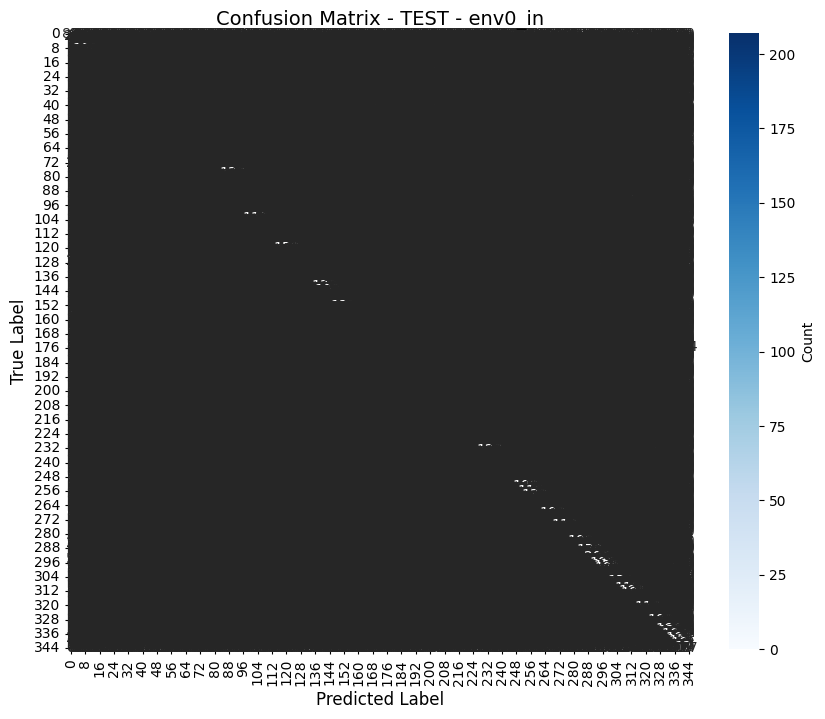


TRAIN - env1_in:
  Loss: 2.9636
  Accuracy: 0.1208, Precision: 0.1809, Recall: 0.1208, F1: 0.1298
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env1_in.png


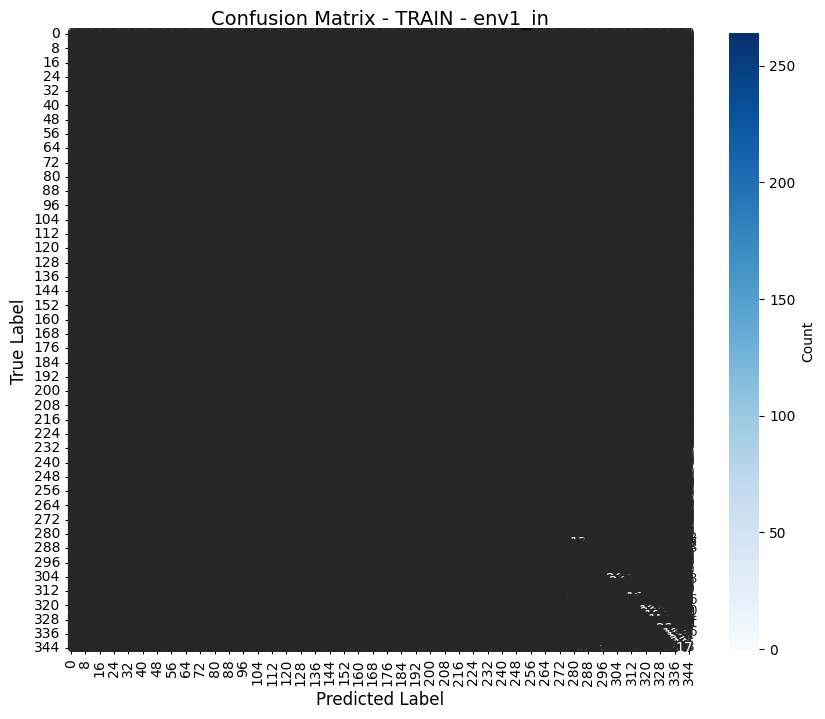


TRAIN - env2_in:
  Loss: 1.3387
  Accuracy: 0.2241, Precision: 0.2786, Recall: 0.2241, F1: 0.2368
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env2_in.png


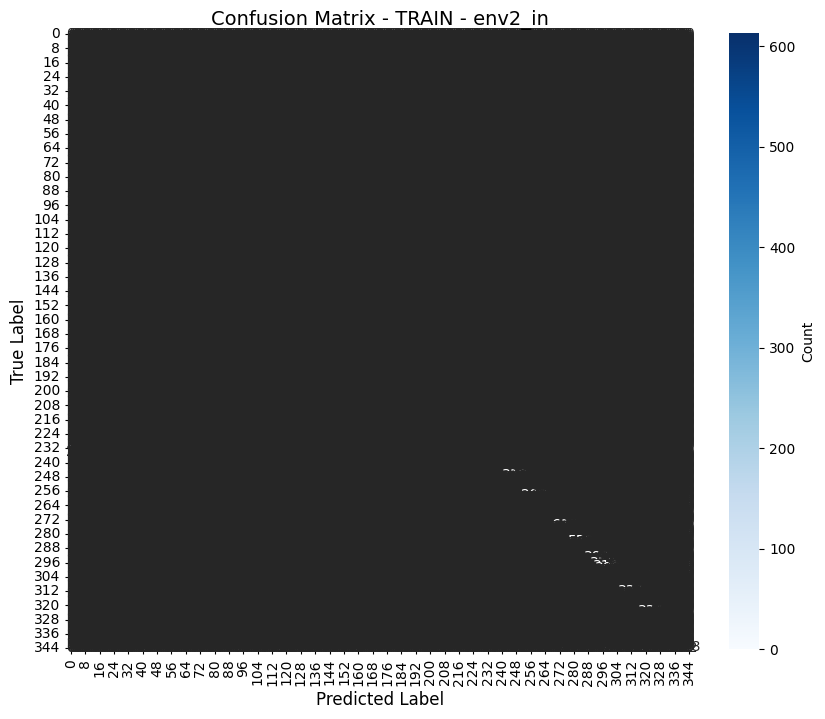


TRAIN - env3_in:
  Loss: 1.1304
  Accuracy: 0.5428, Precision: 0.5679, Recall: 0.5428, F1: 0.5387
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env3_in.png


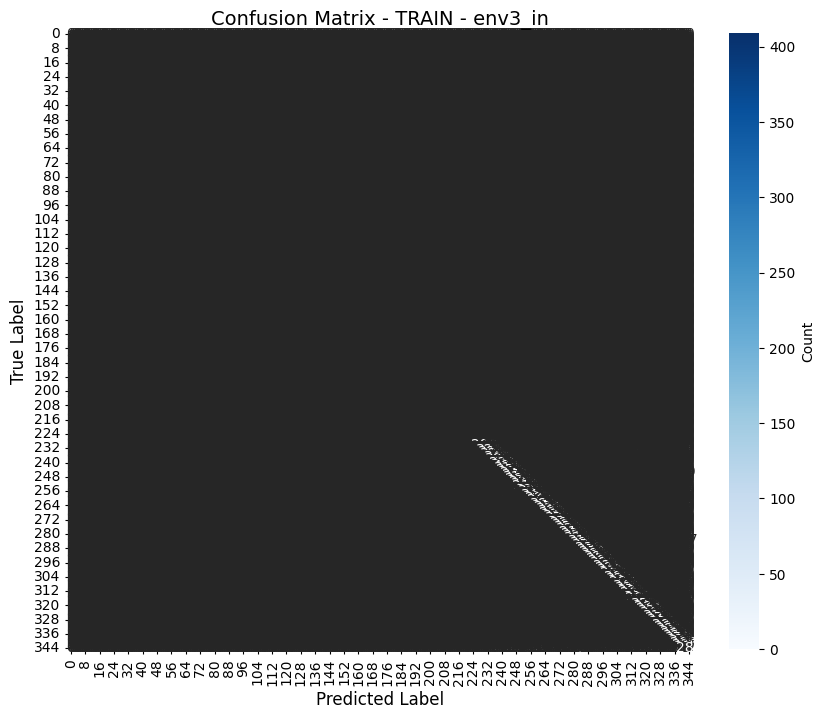


TRAIN - env4_in:
  Loss: 1.6872
  Accuracy: 0.2024, Precision: 0.2722, Recall: 0.2024, F1: 0.2212
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env4_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env4_in.png


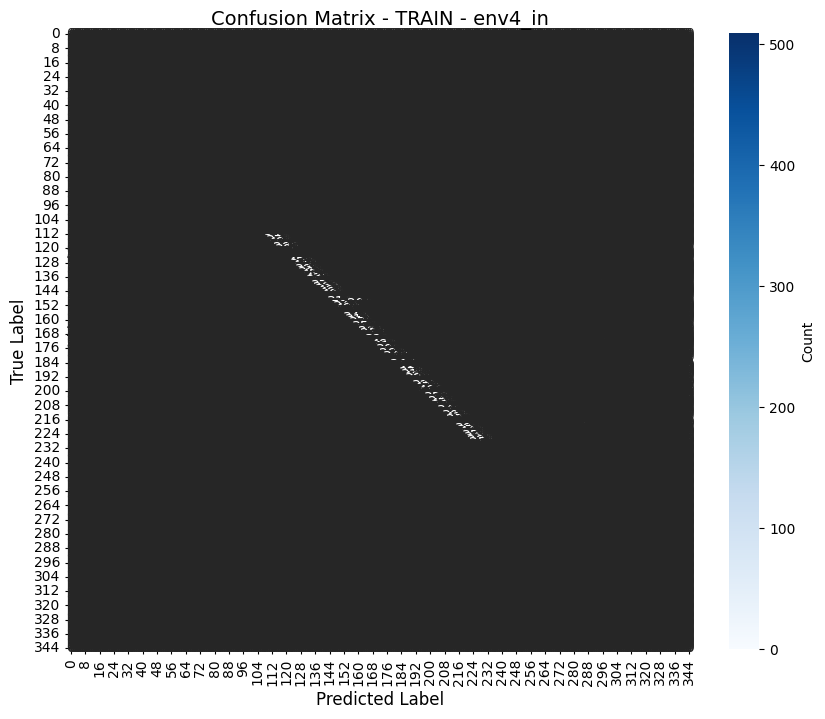


TRAIN - env5_in:
  Loss: 1.6311
  Accuracy: 0.1965, Precision: 0.2592, Recall: 0.1965, F1: 0.2081
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env5_in.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_TRAIN_env5_in.png


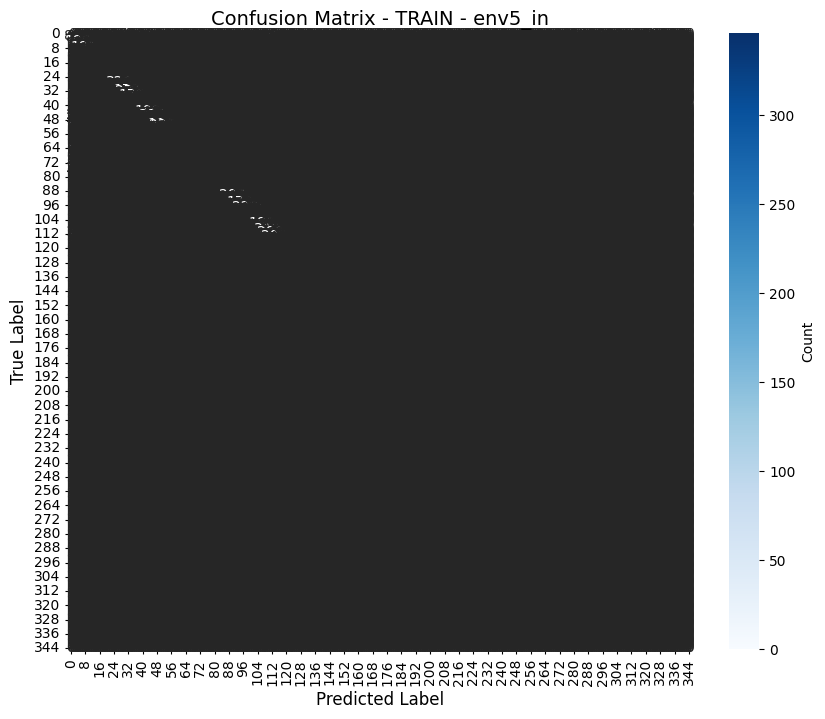


OTHER - env0_out:
  Loss: 3.6500
  Accuracy: 0.2825, Precision: 0.3370, Recall: 0.2825, F1: 0.2603
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_OTHER_env0_out.png


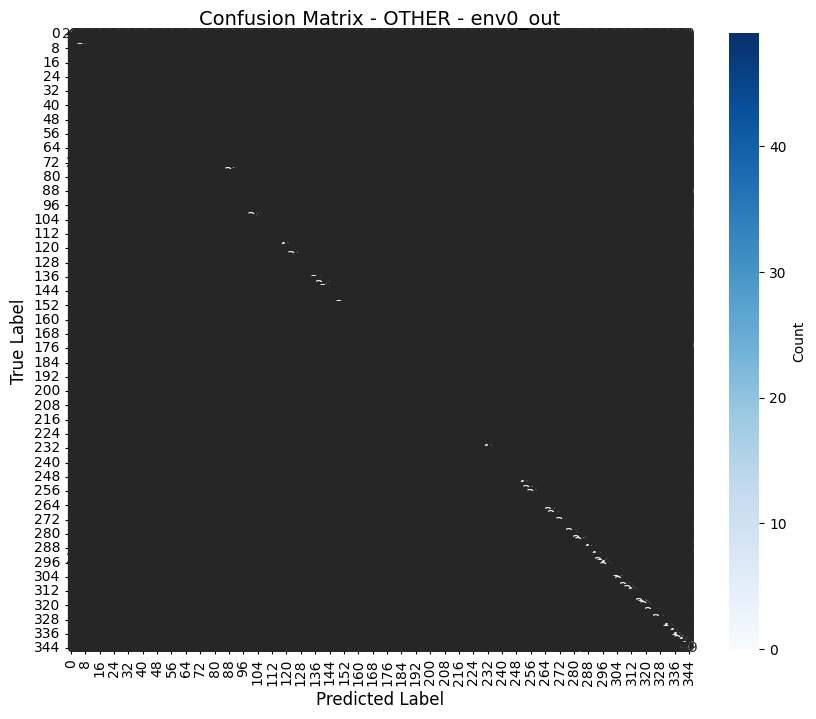


VAL - env1_out:
  Loss: 3.3114
  Accuracy: 0.1181, Precision: 0.1670, Recall: 0.1181, F1: 0.1223
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env1_out.png


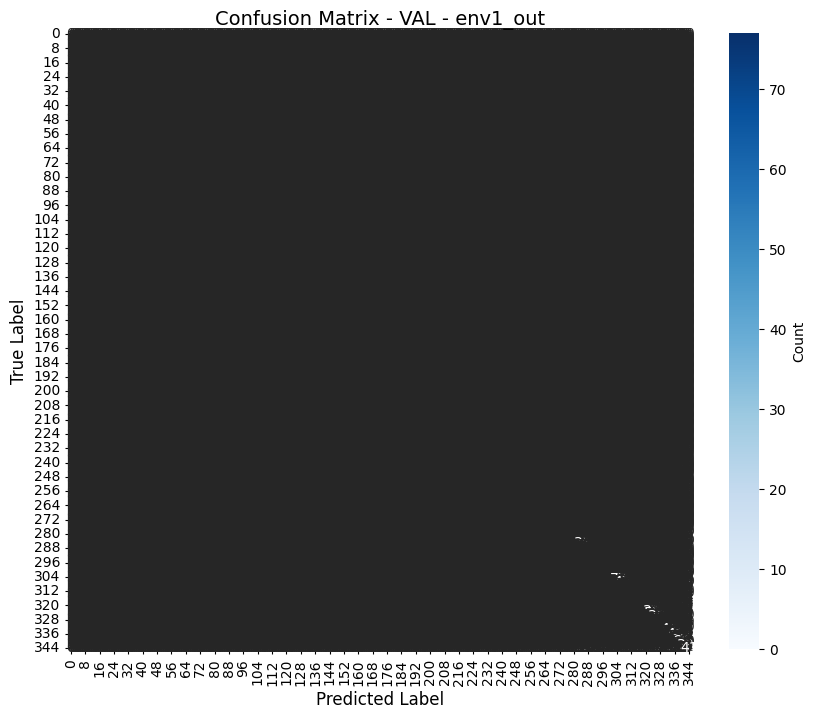


VAL - env2_out:
  Loss: 1.7077
  Accuracy: 0.2156, Precision: 0.2701, Recall: 0.2156, F1: 0.2233
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env2_out.png


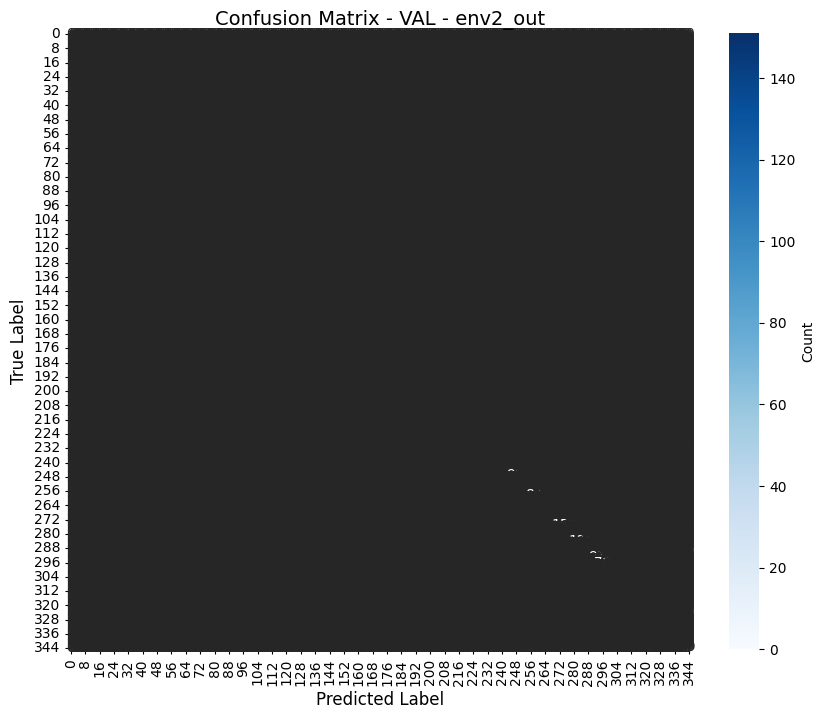


VAL - env3_out:
  Loss: 1.2243
  Accuracy: 0.6080, Precision: 0.6387, Recall: 0.6080, F1: 0.6048
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env3_out.png


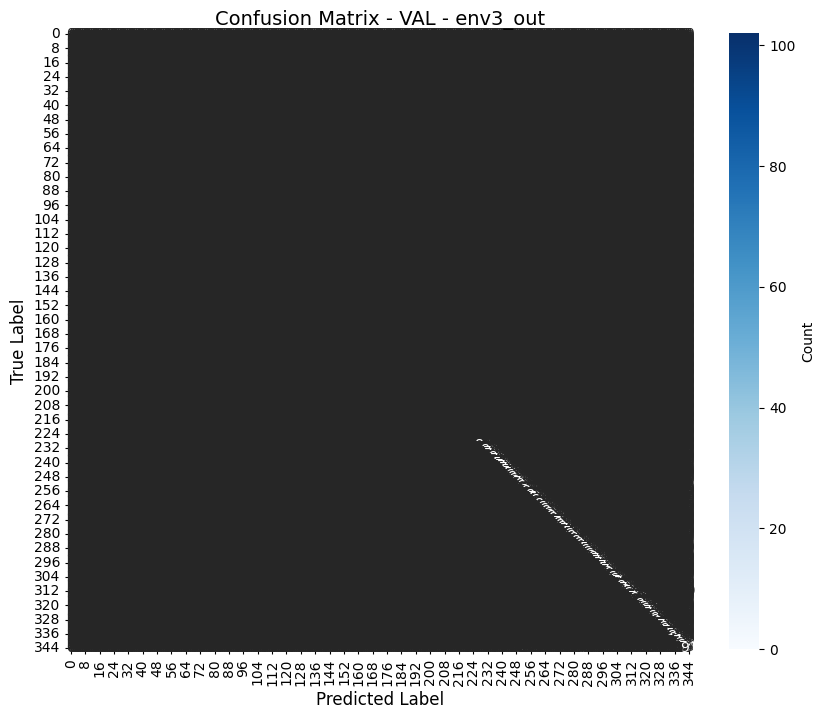


VAL - env4_out:
  Loss: 1.7940
  Accuracy: 0.2131, Precision: 0.2914, Recall: 0.2131, F1: 0.2342
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env4_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env4_out.png


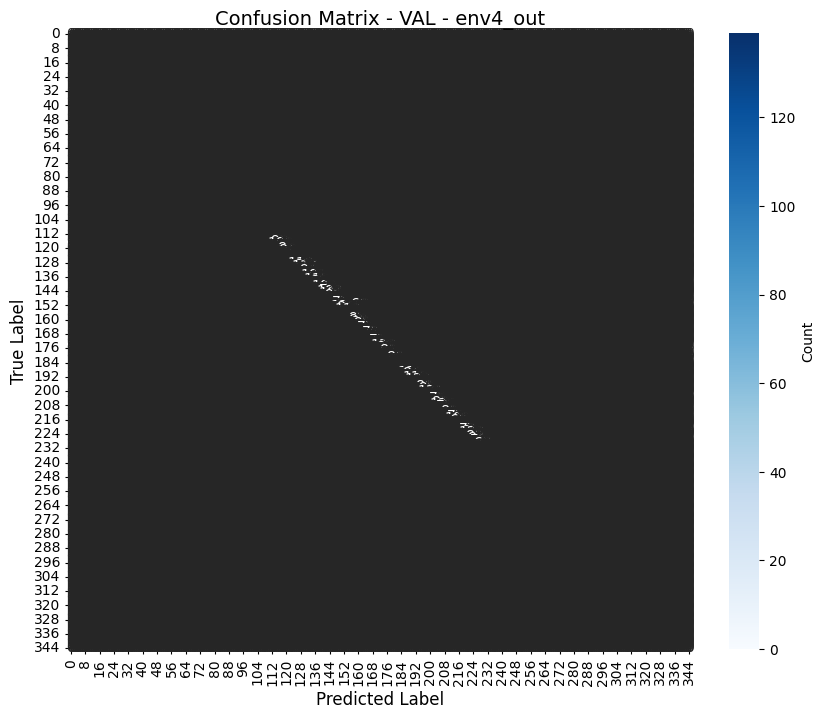


VAL - env5_out:
  Loss: 1.9415
  Accuracy: 0.2058, Precision: 0.2543, Recall: 0.2058, F1: 0.2156
  Saved CSV to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env5_out.csv
  Saved plot to: /kaggle/working/experiments/third_experiment/logs/confusion_matrix_VAL_env5_out.png


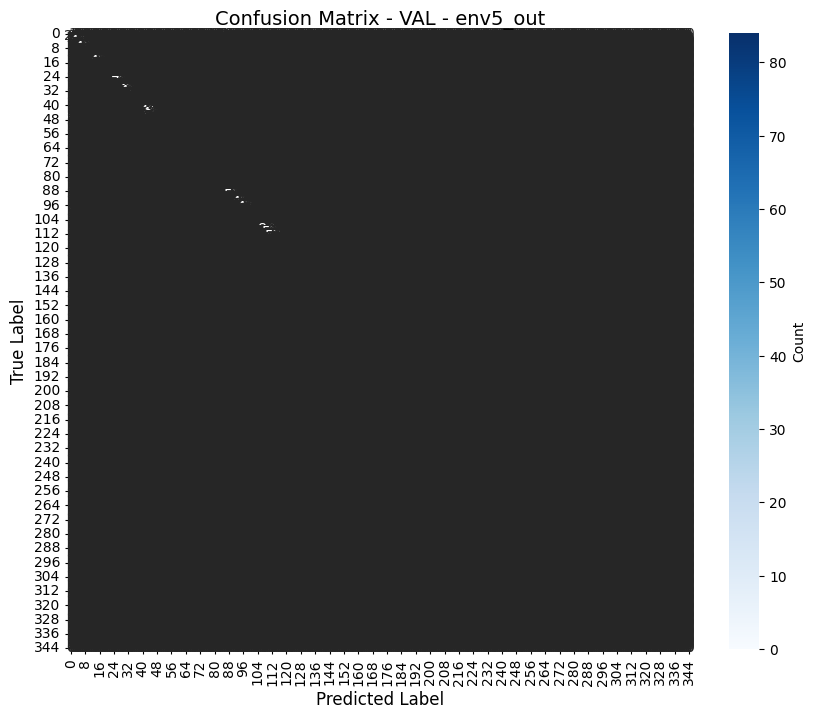


Training curves saved to: /kaggle/working/experiments/third_experiment/logs/training_curves_DomainNet.png


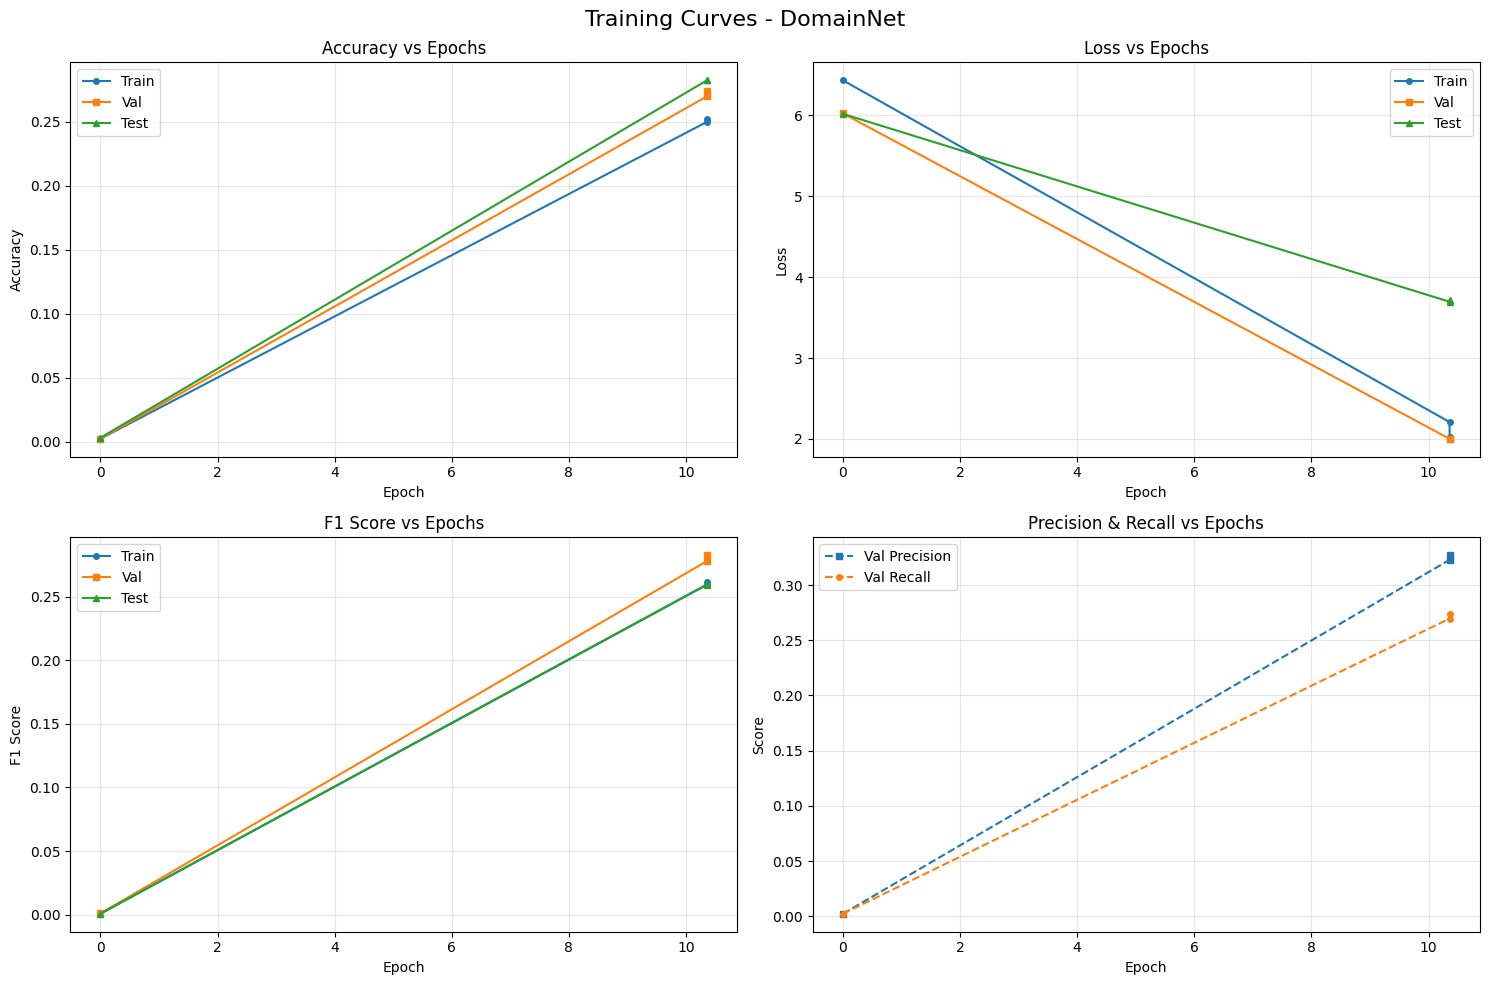

Epoch time plot saved to: /kaggle/working/experiments/third_experiment/logs/epoch_times_DomainNet.png


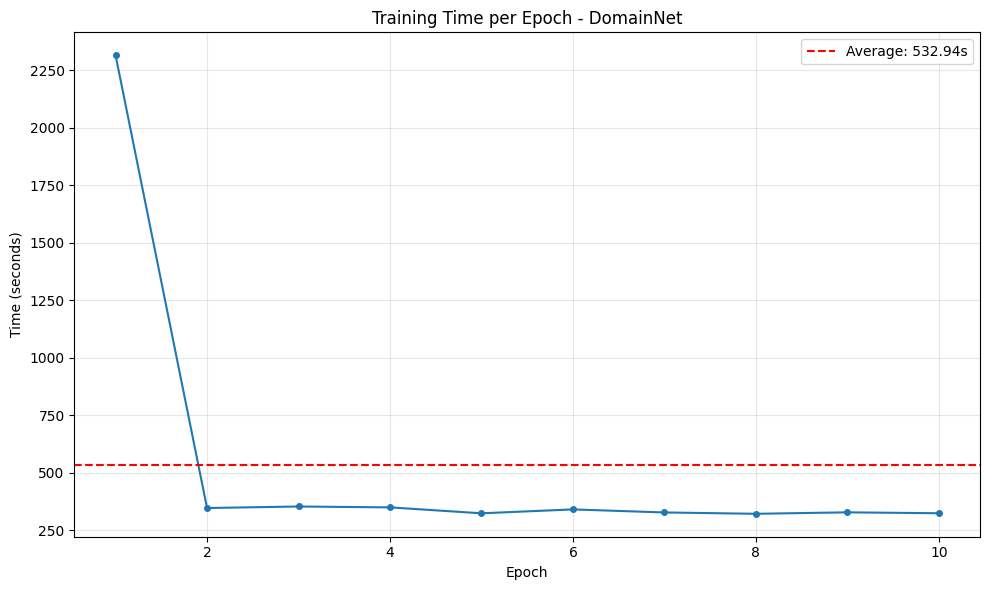


All results saved to: /kaggle/working/experiments/third_experiment/logs

Summary of saved files:
  - model_statistics.json
  - training_time_statistics.json
  - epoch_history.json
  - training_curves_DomainNet.png
  - epoch_times_DomainNet.png
  - confusion_matrix_*.csv (for all splits)
  - confusion_matrix_*.png (heatmaps for all splits)


In [21]:
fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config.get("overall_seed", 1),
    trial_seed=config.get("trial_id", 0),
    hparams_seed=config.get("hparam_id", 0),
    algorithm_name=config["algo"],
    dataset_name=dataset_name,
    data_dir=config["data_dir"][dataset_name],
    num_workers=config.get("num_workers", 4),
    test_envs=[config["test_set_id"]],
    overlap_type='0',  # <- this is correct now
    holdout_fraction=config.get("holdout_fraction", 0.2),
    n_steps=config.get("n_epochs", 5001),
    checkpoint_freq=config.get("checkpoint_freq", 4999),
    model_checkpoint=config.get("model_checkpoint", {"metric": "val/oacc", "maximize": True}),
    num_domain_linked_classes=config.get("num_domain_linked_classes"),
    num_classes=config.get("num_classes"),
    auto_augment=config.get("auto_augment", False),
    augment_search_epochs=config.get("augment_search_epochs", 10),
)


# OLD

In [26]:
fit_simple(
    exp_dir=str(exp_dir),
    logger=logger,
    seed=config.get("overall_seed", 1),
    trial_seed=config.get("trial_id", 0),
    hparams_seed=config.get("hparam_id", 0),
    algorithm_name=config["algo"],
    dataset_name=dataset_name,
    data_dir=config["data_dir"][dataset_name],
    num_workers=config.get("num_workers", 4),
    test_envs=[config["test_set_id"]],
    overlap_type = "none",  # <--- fixed here
    holdout_fraction=config.get("holdout_fraction", 0.2),
    n_steps=config.get("n_epochs", 5001),
    checkpoint_freq=config.get("checkpoint_freq", 4999),
    model_checkpoint=config.get("model_checkpoint", {"metric": "val/oacc", "maximize": True}),
    num_domain_linked_classes=config.get("num_domain_linked_classes"),
    num_classes=config.get("num_classes"),
    auto_augment=config.get("auto_augment", False),
    augment_search_epochs=config.get("augment_search_epochs", 10),
)


Seed set to 1


KeyError: 'none'